In [28]:
# ================================
# IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# ================================
# LOAD DATASET
# ================================

# Change this path if needed


df = pd.read_csv("/content/ai4i2020.csv")

print("Dataset Loaded Successfully ✅")
df.head()

Dataset Loaded Successfully ✅


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [30]:
# ================================
# BASIC CLEANING
# ================================

# Drop unnecessary columns
df = df.drop(columns=["UDI", "Product ID"])

# Check nulls
print(df.isnull().sum())

# Check duplicates
print("Duplicates:", df.duplicated().sum())

Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64
Duplicates: 0


In [31]:
# ================================
# FEATURE ENGINEERING
# ================================

# Convert Type → Numeric
df["Type"] = df["Type"].map({"L": 0, "M": 1, "H": 2})

print(df["Type"].value_counts())



Type
0    6000
1    2997
2    1003
Name: count, dtype: int64


In [6]:
# -------------------------------
# Temperature Features
# -------------------------------
df["Temp_Diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["Temp_Ratio"] = df["Process temperature [K]"] / df["Air temperature [K]"]
df["Temp_Avg"] = (df["Process temperature [K]"] + df["Air temperature [K]"]) / 2

print("\nTemperature Features:")
print(df[["Temp_Diff","Temp_Ratio","Temp_Avg"]].head())



Temperature Features:
   Temp_Diff  Temp_Ratio  Temp_Avg
0       10.5    1.035223    303.35
1       10.5    1.035211    303.45
2       10.4    1.034888    303.30
3       10.4    1.034876    303.40
4       10.5    1.035211    303.45


In [7]:
# -------------------------------
# Load & Stress Features
# -------------------------------
df["Stress"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"]
df["Power"] = (df["Torque [Nm]"] * df["Rotational speed [rpm]"]) / 9550
df["Thermal_Stress"] = df["Process temperature [K]"] * df["Torque [Nm]"]

print("\nStress Features:")
print(df[["Stress","Power","Thermal_Stress"]].head())


Stress Features:
    Stress     Power  Thermal_Stress
0  66382.8  6.951079        13208.08
1  65190.4  6.826220        14292.81
2  74001.2  7.748817        15239.90
3  56603.5  5.927068        12189.70
4  56320.0  5.897382        12348.00


In [8]:
# -------------------------------
# Wear Features
# -------------------------------
df["Wear_Rate"] = df["Tool wear [min]"] / (df["Rotational speed [rpm]"] + 1)
df["Wear_Impact"] = df["Tool wear [min]"] * df["Torque [Nm]"]
df["Normalized_Wear"] = df["Tool wear [min]"] / df["Tool wear [min]"].max()

print("\nWear Features:")
print(df[["Wear_Rate","Wear_Impact","Normalized_Wear"]].head())



Wear Features:
   Wear_Rate  Wear_Impact  Normalized_Wear
0   0.000000          0.0         0.000000
1   0.002129        138.9         0.011858
2   0.003336        247.0         0.019763
3   0.004881        276.5         0.027668
4   0.006388        360.0         0.035573


In [9]:
# -------------------------------
# Ratio Features
# -------------------------------
df["Torque_Speed_Ratio"] = df["Torque [Nm]"] / (df["Rotational speed [rpm]"] + 1)
df["Efficiency"] = df["Rotational speed [rpm]"] / (df["Torque [Nm]"] + 1)
df["Temperature_Speed_Ratio"] = df["Process temperature [K]"] / (df["Rotational speed [rpm]"] + 1)

print("\nRatio Features:")
print(df[["Torque_Speed_Ratio","Efficiency","Temperature_Speed_Ratio"]].head())


Ratio Features:
   Torque_Speed_Ratio  Efficiency  Temperature_Speed_Ratio
0            0.027577   35.410959                 0.198840
1            0.032860   29.767442                 0.219092
2            0.032955   29.722222                 0.205804
3            0.027545   35.382716                 0.215202
4            0.028389   34.341463                 0.219092


In [10]:
# -------------------------------
# Risk & Flags
# -------------------------------
df["High_Temp_Flag"] = (df["Process temperature [K]"] > 310).astype(int)
df["High_Wear_Flag"] = (df["Tool wear [min]"] > 150).astype(int)
df["High_Torque_Flag"] = (df["Torque [Nm]"] > 50).astype(int)

df["Risk_Score"] = (
    df["Tool wear [min]"] * 0.4 +
    df["Torque [Nm]"] * 0.3 +
    df["Temp_Diff"] * 0.3
)

print("\nRisk & Flags:")
print(df[["High_Temp_Flag","High_Wear_Flag","High_Torque_Flag","Risk_Score"]].head())


Risk & Flags:
   High_Temp_Flag  High_Wear_Flag  High_Torque_Flag  Risk_Score
0               0               0                 0       15.99
1               0               0                 0       18.24
2               0               0                 0       19.94
3               0               0                 0       17.77
4               0               0                 0       18.75


In [11]:

# ================================
# CHECK + DROP FAILURE COLUMNS SAFELY
# ================================

# Step 1: Show current columns
print("Columns before dropping:")
print(df.columns)

# Step 2: Define columns to drop
cols_to_drop = ["TWF", "HDF", "PWF", "OSF", "RNF"]

# Step 3: Check which columns actually exist
existing_cols = [col for col in cols_to_drop if col in df.columns]

# Step 4: Drop only existing columns
df = df.drop(columns=existing_cols)

# Step 5: Confirmation
print("\nDropped Columns:", existing_cols)

print("\nColumns after dropping:")
print(df.columns)

Columns before dropping:
Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Temp_Diff',
       'Temp_Ratio', 'Temp_Avg', 'Stress', 'Power', 'Thermal_Stress',
       'Wear_Rate', 'Wear_Impact', 'Normalized_Wear', 'Torque_Speed_Ratio',
       'Efficiency', 'Temperature_Speed_Ratio', 'High_Temp_Flag',
       'High_Wear_Flag', 'High_Torque_Flag', 'Risk_Score'],
      dtype='object')

Dropped Columns: ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Columns after dropping:
Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'Temp_Diff', 'Temp_Ratio', 'Temp_Avg', 'Stress',
       'Power', 'Thermal_Stress', 'Wear_Rate', 'Wear_Impact',
       'Normalized_Wear', 'Torque_Speed_Ratio', 'Efficiency',
       'Temperature_Speed_Ratio', 'High_Temp_Flag', 'High_Wear_Fl

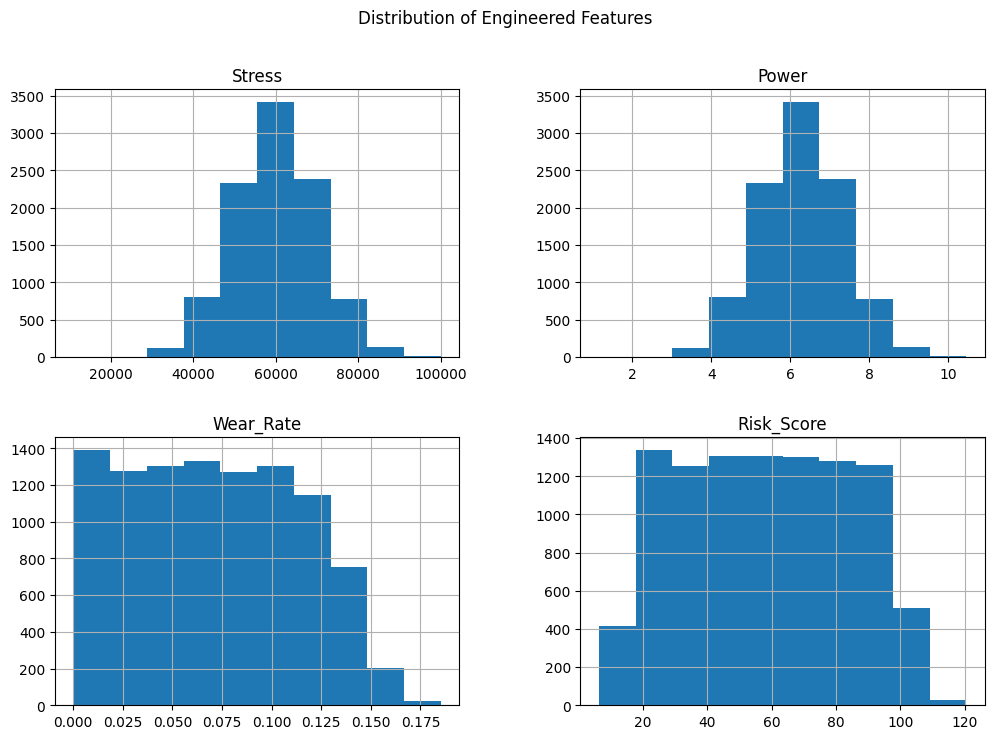

In [12]:
df[["Stress", "Power", "Wear_Rate", "Risk_Score"]].hist(figsize=(12,8))
plt.suptitle("Distribution of Engineered Features")
plt.show()

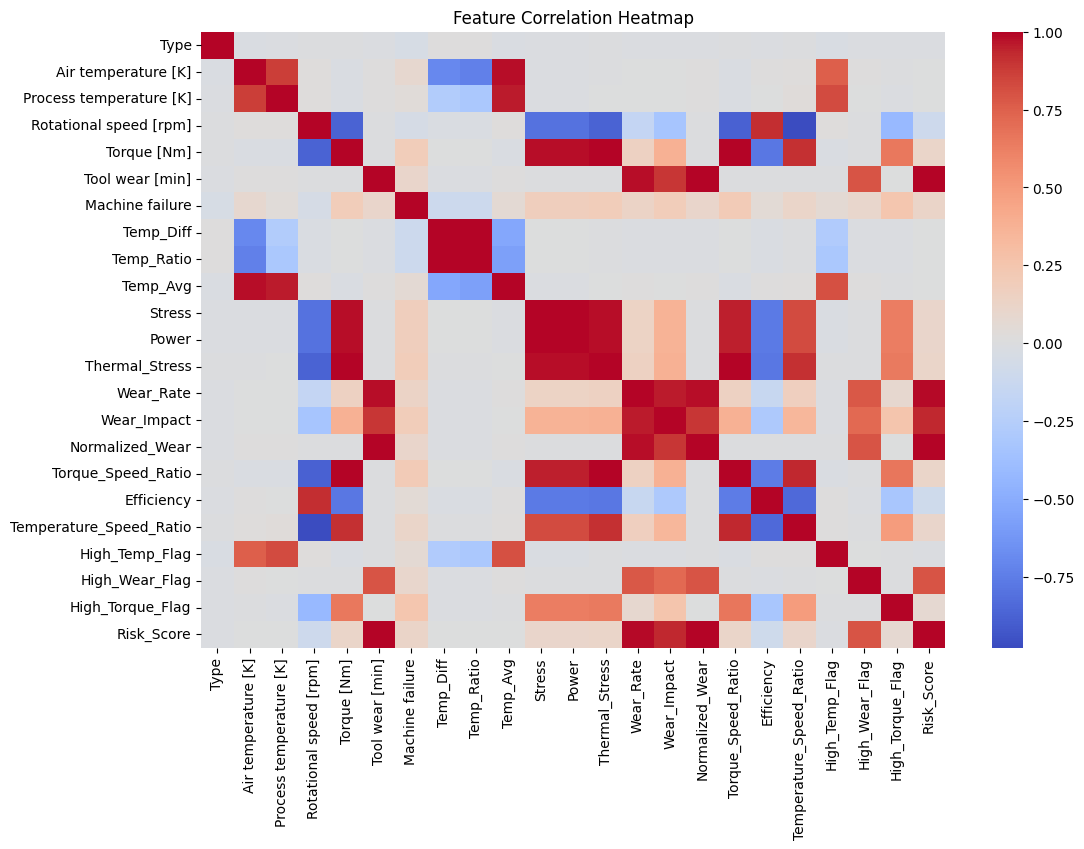

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

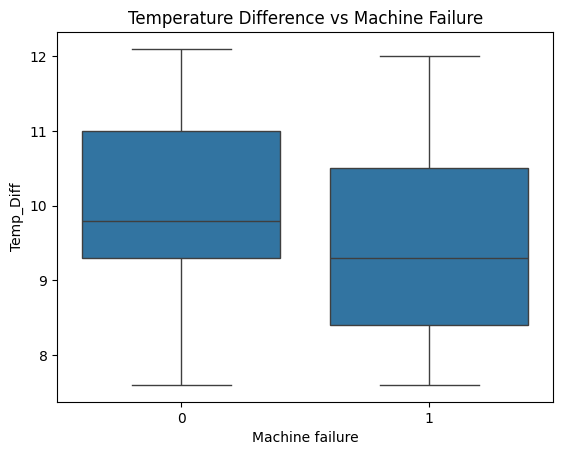

In [21]:
sns.boxplot(x=df["Machine failure"], y=df["Temp_Diff"])
plt.title("Temperature Difference vs Machine Failure")
plt.show()

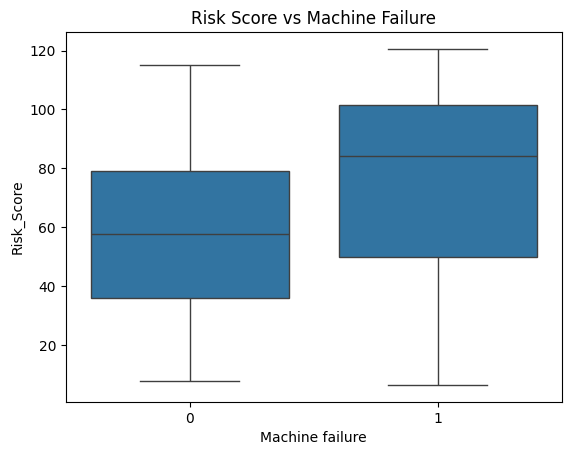

In [20]:

sns.boxplot(x=df["Machine failure"], y=df["Risk_Score"])
plt.title("Risk Score vs Machine Failure")
plt.show()

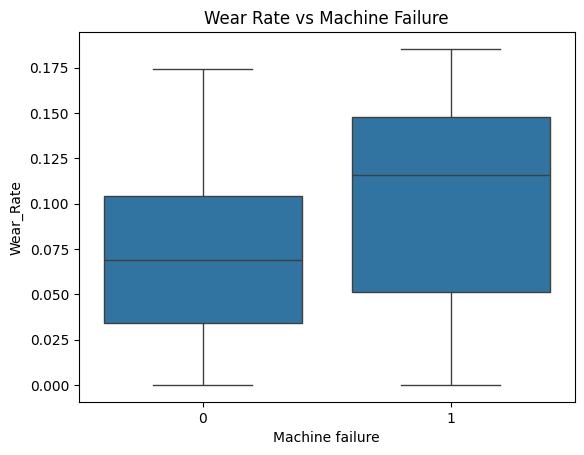

In [19]:
sns.boxplot(x=df["Machine failure"], y=df["Wear_Rate"])
plt.title("Wear Rate vs Machine Failure")
plt.show()

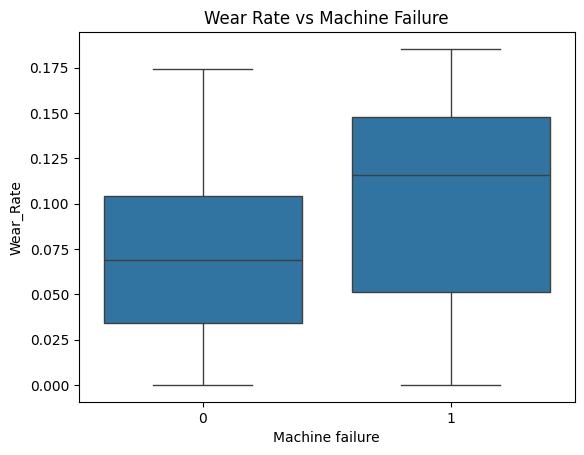

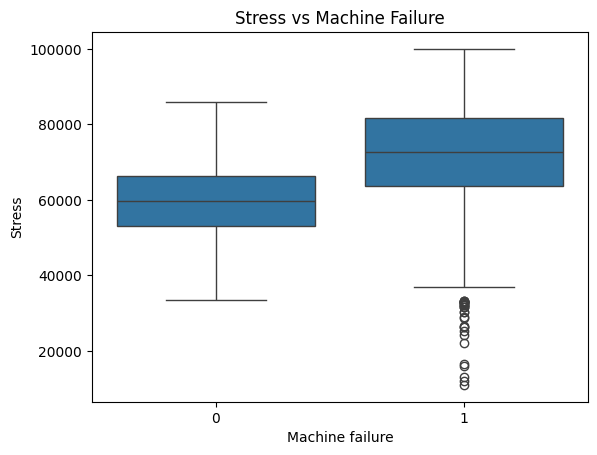

In [18]:

sns.boxplot(x=df["Machine failure"], y=df["Stress"])
plt.title("Stress vs Machine Failure")
plt.show()

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64
Machine failure
0    9661
1     339
Name: count, dtype: int64


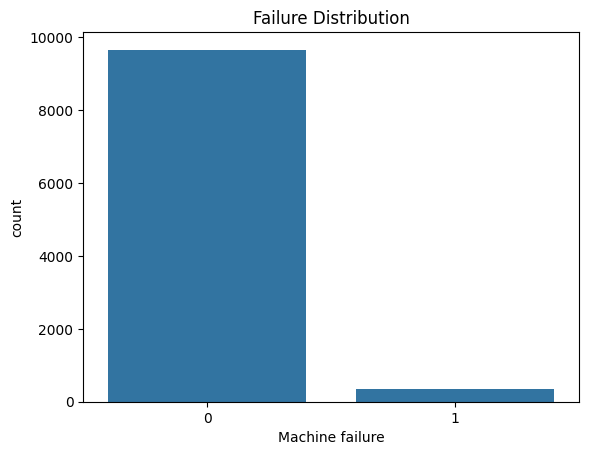

In [22]:
percentages = df["Machine failure"].value_counts(normalize=True) * 100
print(percentages)

machine_failure_counts = df["Machine failure"].value_counts()
print(machine_failure_counts)

sns.countplot(x=df["Machine failure"])
plt.title("Failure Distribution")
plt.show()

In [ ]:
print("Final Columns:\n", df.columns)
print("\nDataset Shape:", df.shape)

df.head()

Final Columns:
 Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'Temp_Diff', 'Temp_Ratio', 'Temp_Avg', 'Stress',
       'Power', 'Thermal_Stress', 'Wear_Rate', 'Wear_Impact',
       'Normalized_Wear', 'Torque_Speed_Ratio', 'Efficiency', 'High_Temp_Flag',
       'High_Wear_Flag', 'High_Torque_Flag', 'Risk_Score'],
      dtype='object')

Dataset Shape: (10000, 22)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temp_Diff,Temp_Ratio,Temp_Avg,...,Thermal_Stress,Wear_Rate,Wear_Impact,Normalized_Wear,Torque_Speed_Ratio,Efficiency,High_Temp_Flag,High_Wear_Flag,High_Torque_Flag,Risk_Score
0,1,298.1,308.6,1551,42.8,0,0,10.5,1.035223,303.35,...,13208.08,0.000000,0.0,0.000000,0.027577,35.410959,0,0,0,15.99
1,0,298.2,308.7,1408,46.3,3,0,10.5,1.035211,303.45,...,14292.81,0.002129,138.9,0.011858,0.032860,29.767442,0,0,0,18.24
2,0,298.1,308.5,1498,49.4,5,0,10.4,1.034888,303.30,...,15239.90,0.003336,247.0,0.019763,0.032955,29.722222,0,0,0,19.94
3,0,298.2,308.6,1433,39.5,7,0,10.4,1.034876,303.40,...,12189.70,0.004881,276.5,0.027668,0.027545,35.382716,0,0,0,17.77
4,0,298.2,308.7,1408,40.0,9,0,10.5,1.035211,303.45,...,12348.00,0.006388,360.0,0.035573,0.028389,34.341463,0,0,0,18.75


In [ ]:
# Create folder if not exists
os.makedirs("processed_data", exist_ok=True)

df.to_csv("processed_data/ai4i2020_feature_engineered.csv", index=False)

print("✅ Feature Engineered Dataset Saved Successfully!")

✅ Feature Engineered Dataset Saved Successfully!
